In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy
from scipy.sparse import csr_matrix
import yaml
# import pyranges as pr

import anndata as an
import scanpy as sc

# Load GTF

In [2]:
%%time 
# === Load and filter GTF ===
# gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"
gpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/RefGenome/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)
print(f"Total entries in GTF: {len(gtf)}")

# Transcript-level annotations
transcripts = gtf[gtf.Feature == "transcript"]
transcripts = transcripts[[
    "gene_id", "gene_name", "gene_type",
    "transcript_id", "transcript_name", "transcript_type",
    "Chromosome", "Start", "End"
]].dropna(subset=["gene_name", "transcript_name"]).drop_duplicates().reset_index(drop=True)
print(f"Transcripts loaded: {len(transcripts)}")

# Gene-level annotations
genes = gtf[gtf.Feature == "gene"]
genes = genes[[
    "gene_id", "gene_name", "gene_type",
    "Chromosome", "Start", "End"
]].dropna(subset=["gene_name"]).drop_duplicates().reset_index(drop=True)
print(f"Genes loaded: {len(genes)}")

Total entries in GTF: 3293161
Transcripts loaded: 226005
Genes loaded: 38606
CPU times: user 7.83 s, sys: 1.34 s, total: 9.17 s
Wall time: 9.35 s


# Load in gene data

In [3]:
%%time
# fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/three_libraries_new.h5ad"
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/three_libraries_new.h5ad"
gdata = sc.read_h5ad(fpath)
gdata

CPU times: user 1.5 s, sys: 2.09 s, total: 3.59 s
Wall time: 1min 1s


AnnData object with n_obs × n_vars = 20754 × 26933
    obs: 'dataset', 'source', 'cluster_all', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'Chromosome', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mito', 'filter_pass'
    uns: 'label_colors', 'label_deg', '

In [5]:
gdata.obs.tail()

,dataset,source,cluster_all,group,label,S_score,G2M_score,phase,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,combined_clusters,subgroup
TGTGGTCAGTGAGCCT-1_fib,fibroblasts,fib,C4,initial,initial,-0.186171,-0.155901,G1,2571,7.852439,...,20.408992,38.289084,36.795752,3.632197,1.235664,234.687465,5.462507,7.881202,M5,initial
TGTGGTTGTAGCCCTA-1_fib,fibroblasts,fib,C4,initial,initial,-0.219649,-0.159899,G1,3213,8.075272,...,19.967414,36.711634,39.123495,3.691962,1.280739,237.897788,5.476036,7.787774,M7,initial
TGTGGTTGTTGAAGGC-1_fib,fibroblasts,fib,C4,initial,initial,-0.102224,-0.145739,G1,3578,8.182839,...,19.226907,35.418035,40.651220,3.729331,1.276729,234.775857,5.462882,7.373582,M7,initial
TGTGTTAGTTGGTAAG-1_fib,fibroblasts,fib,C4,initial,initial,-0.141990,-0.111529,G1,2433,7.797291,...,21.486380,38.669724,35.095512,3.586169,1.224487,256.161699,5.549705,8.937512,M5,initial
TGTGTTGAGCCTATCT-1_fib,fibroblasts,fib,C5,initial,initial,-0.070935,0.510054,G2M,3704,8.217439,...,18.817935,34.999147,29.501212,3.417766,0.911457,246.827806,5.512734,7.625891,M6,initial


# Load in raw isoform data

In [6]:
%%time

hsc_subdirs = ['fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3']

fpaths = {
    'fib' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.transcript_raw_feature_bc_matrix",
    'hsc' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/",
    'bm' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/bm_full/bm/bm.transcript_raw_feature_bc_matrix",
}

# Load and tag
adatas = []
for label, path in fpaths.items():
    if not label == 'hsc':
        adata = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
        adata.obs['dataset'] = label
        adata.obs_names = [f"{x}_{label}" for x in adata.obs_names] 
        adatas.append(adata)
        print(f"{label} {adata.shape}")
    else:
        hsc_adatas = []
        for subdir in hsc_subdirs:
            fpath = f"{path}{subdir}/{subdir}.transcript_raw_feature_bc_matrix"
            adata = sc.read_10x_mtx(fpath, var_names='gene_symbols', cache=True)
            adata.obs['cell_id'] = adata.obs_names
            hsc_adatas.append(adata)
            print(f"HSC {subdir} {adata.shape}")

        adata = an.concat(hsc_adatas, join='outer', keys=hsc_subdirs)
        adata = sc.get.aggregate(
            adata, 
            by='cell_id',
            func='sum',
        )
        adata.X = adata.layers['sum']
        del adata.layers['sum']
        del adata.obs['cell_id']
        adata.obs['dataset'] = label
        adata.obs_names = [f"{x}_{label}" for x in adata.obs_names]
        adatas.append(adata)

# Concatenate into one AnnData object
adata = an.concat(adatas, join='outer', label='dataset', keys=fpaths.keys())

transcripts_indexed = transcripts.drop_duplicates(subset='transcript_name').set_index('transcript_id')
var_annot = adata.var.join(transcripts_indexed, how='left')
adata.var = var_annot
adata.var['transcript_id'] = adata.var.index.copy()
adata.var_names = adata.var['transcript_name'].copy()

adata

fib (8963, 63464)
HSC fast_v3 (9279, 11124)
HSC minion_384 (8579, 39453)
HSC fast_v4.2 (8426, 12175)
HSC hac_v4.2 (8657, 60494)
HSC hac_v4.3 (8579, 39922)
HSC hac_v3 (8576, 53841)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


bm (6269, 74815)
CPU times: user 26.7 s, sys: 6.26 s, total: 32.9 s
Wall time: 34.8 s


AnnData object with n_obs × n_vars = 26193 × 113335
    obs: 'dataset'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'

In [7]:
adata.obs['dataset'].value_counts()

dataset
hsc    10961
fib     8963
bm      6269
Name: count, dtype: int64

# filter cells and ensure ordering

In [8]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in gdata: {gdata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(gdata.obs_names)
print(f"Number of cells in adata after filtering by gdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = gdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
gdata_sorted = gdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == gdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and gdata (shared cells).")
adata

Initial number of cells in adata: 26193
Number of cells in gdata: 20754
Number of cells in adata after filtering by gdata: 20754
Final number of cells in adata: 20754
Number of shared cells: 20754
Cell ordering is identical between adata and gdata (shared cells).
CPU times: user 1.58 s, sys: 3.91 s, total: 5.49 s
Wall time: 5.6 s


AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'

In [9]:
gdata.obs.columns

Index(['dataset', 'source', 'cluster_all', 'group', 'label', 'S_score',
       'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mito',
       'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters',
       'subgroup'],
      dtype='object')

In [10]:
print(gdata.obs['source'].value_counts())
print(gdata.obs['cluster_all'].value_counts())
print(gdata.obs['group'].value_counts())
print(gdata.obs['label'].value_counts())
print(gdata.obs['combined_clusters'].value_counts())
print(gdata.obs['subgroup'].value_counts())

source
hsc            8336
fib            6960
bone_marrow    5458
Name: count, dtype: int64
cluster_all
C4    4612
R2    4323
C5    3852
B1    2162
R1    1985
B5    1506
R3     524
B7     500
B2     496
B4     440
B3     302
B6      52
Name: count, dtype: int64
group
initial      8464
reprogram    6832
bm_other     3952
target       1506
Name: count, dtype: int64
label
initial    8464
R2         4323
MPP        2162
R1         1985
HSC        1506
R3          524
CLP         500
LMPP        496
MEG-ERY     440
CMP         302
GMP          52
Name: count, dtype: int64
combined_clusters
M6     2236
M7     2063
M4     1977
M9     1786
M14    1561
M3     1531
M5     1530
M1     1439
M8     1102
M2     1035
M11    1028
M12     899
M10     757
M13     687
M15     628
M16     495
Name: count, dtype: int64
subgroup
initial        8464
R2             4323
progenitors    2956
R1             1985
HSC            1506
R3              524
CLP             500
LMPP            496
Name: count, dtype: 

# merge obs

In [12]:
%%time

obs_columns = [
    'source',
    'label',
    'cluster_all',
    'group',
    'subgroup',
    # 'batch',
    'phase',
    # 'cluster_str',
    'S_score',
    'G2M_score',
    # 'mean_pseudotime',
    # 'mean_order',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = gdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_gdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")
print(f"Example merged obs (first 5 rows):\n{adata.obs.head()}")

Before merge: adata.obs columns = ['dataset']
After merge: adata.obs columns = ['dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score']
Example merged obs (first 5 rows):
                      dataset       source    label cluster_all     group  \
AAACCAAAGGCGATCT-1_bm      bm  bone_marrow      MPP          B1  bm_other   
AAACCAAAGGTGAACG-1_bm      bm  bone_marrow  MEG-ERY          B4  bm_other   
AAACCATTCCCTGTCA-1_bm      bm  bone_marrow      CMP          B3  bm_other   
AAACCATTCCGCGATG-1_bm      bm  bone_marrow      HSC          B5    target   
AAACCATTCCTGTCGC-1_bm      bm  bone_marrow      MPP          B1  bm_other   

                          subgroup phase   S_score  G2M_score  
AAACCAAAGGCGATCT-1_bm  progenitors     S  0.143122  -0.065602  
AAACCAAAGGTGAACG-1_bm  progenitors    G1 -0.190987  -0.160053  
AAACCATTCCCTGTCA-1_bm  progenitors   G2M  0.031694   1.140976  
AAACCATTCCGCGATG-1_bm          HSC    G1 -0.136122  -0.099531  
AAA

In [15]:
adata

AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

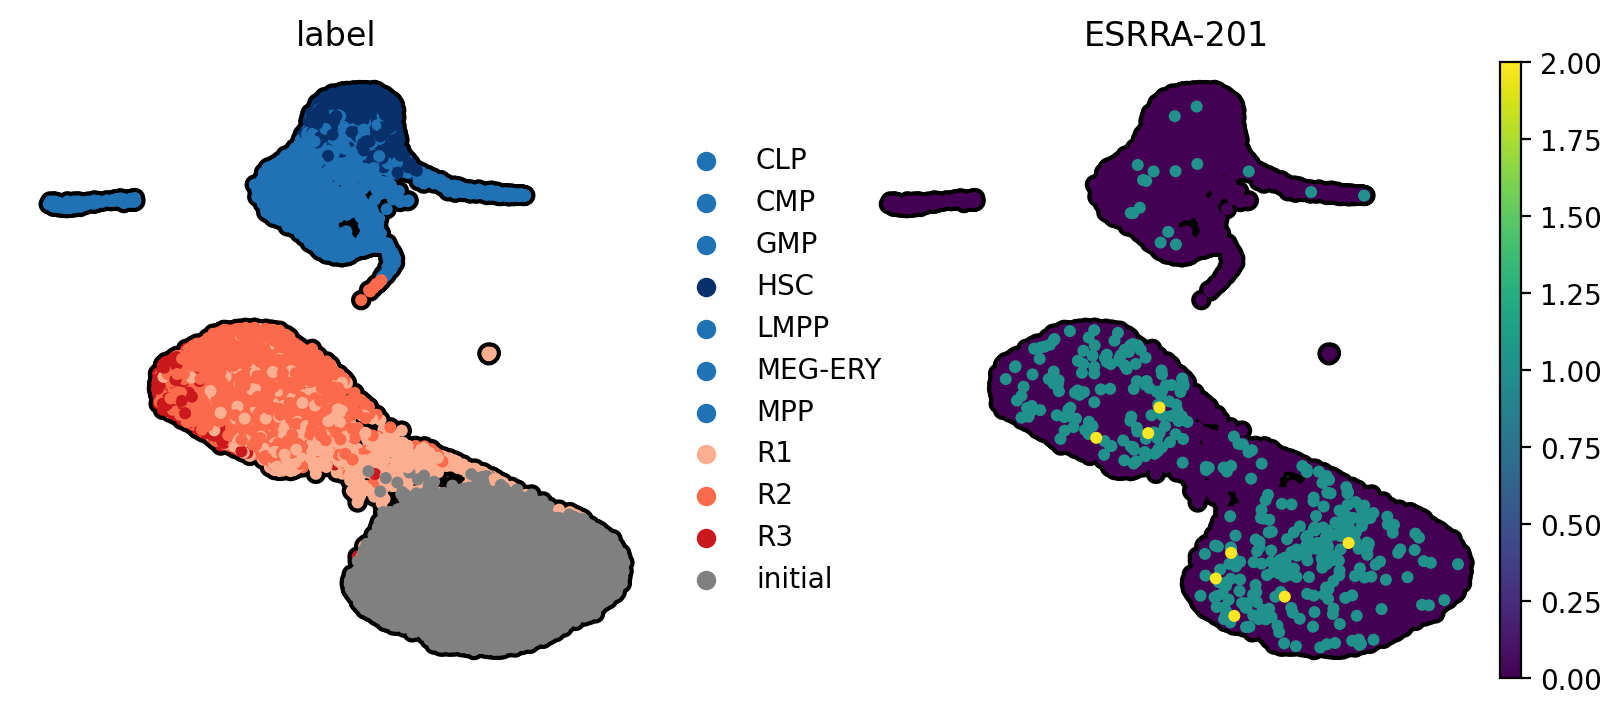

In [14]:
adata.obsm['X_umap'] = gdata.obsm['X_umap'].copy()
adata.uns['label_colors'] = gdata.uns['label_colors'].copy()
adata.uns['label_deg'] = gdata.uns['label_deg'].copy()
adata.uns['scvi_expression'] = gdata.uns['scvi_expression'].copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=2,
    sort_order=True,
    color=['label', 'ESRRA-201'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

# Write out

In [16]:
%%time
outpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/isoforms.h5ad"
adata.write(outpath)
print(f"saved to: {outpath}")
adata

saved to: /scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/isoforms.h5ad
CPU times: user 2.02 s, sys: 238 ms, total: 2.26 s
Wall time: 6.99 s


AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

In [ ]:
# file moved to Turbo: /nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/isoforms.h5ad